In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


#final_speed = 20.
num_cores = 200
maxtime = 1435
#runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
runID = "Fasymp2_fixgaussian20_50GW" # _nG30"

student = "Grating_Half"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "combine_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 731622
Average function evaluations per core: 3658


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
from scipy.optimize import minimize
from parameters import D1_ND

def get_final(l_min, l_max):
    doppler = l_min / l_max

    def test(v):
        v = v/100
        return np.abs(doppler - D1_ND(v))

    sol = minimize(test, 5)
    final_speed = sol.x[0]
    return final_speed

In [4]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 17

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[1, np.float64(1.049999999971945)]
Total function evaluations: 731622
Average function evaluations per core: 3658
TORCWA
[tensor(1.6442, dtype=torch.float64), tensor(0.4207, dtype=torch.float64), tensor(0.4393, dtype=torch.float64), tensor(0.0699, dtype=torch.float64), tensor(0.7073, dtype=torch.float64), tensor(6.2141, dtype=torch.float64), tensor(10.3459, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.7074, dtype=torch.float64), tensor(5.0511, dtype=torch.float64)]
[tensor(1.6442, dtype=torch.float64), tensor(0.4207, dtype=torch.float64), tensor(0.4393, dtype=torch.float64), tensor(0.0699, dtype=torch.float64), tensor(0.7073, dtype=torch.float64), tensor(6.2141, dtype=torch.float64), tensor(10.3459, dtype=torch.float64), tensor(0.7074, dtype=torch.float64), tensor(5.0511, dtype=torch.float64)]
-15.017300433308518
grating_pitch   = 1.644158094108683
grating_depth   = 0.42065441113361174
box1_width      = 0.43931427220999403
box2_width      = 0.06986396941011432
box_c

In [5]:
scaled = np.sqrt(1.05) # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=1., angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

final_speed = get_final(1., 1.05)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"\nFoM at scaled wavelength: {actual_fom}")

grating_pitch   = 1.6847607041785646
grating_depth   = 0.4310425040369847
box1_width      = 0.45016317181191823
box2_width      = 0.0715892654859949
box_centre_dist = 0.7247638860623848
box1_eps        = 6.214070093349006
box2_eps        = 10.345909666634435
gaussian_width  = 20.4939015319192
substrate_depth = 0.7249060383871563
substrate_eps   = 5.0511030085969155

FoM at scaled wavelength: -36.32971997739088


In [6]:
stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

In [7]:
stiffnesses = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

In [8]:
eigvals = grating.npa.eigvals((J_scaled + J_original)/2)
eigReal = grating.npa.real(eigvals)
eigImag = grating.npa.imag(eigvals)
eigvals

tensor([-0.0004+165.8330j, -0.0004-165.8330j, -0.0002+29.1797j,
        -0.0002-29.1797j], dtype=torch.complex128,
       grad_fn=<LinalgEigBackward0>)

In [9]:
num_plot_points = 200

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating.wavelength = grating.npa.array(lam)
    scaled_grating.wavelength = scaled_grating.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    stiffnesses = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals((J_scaled + J_original)/2)
    
grating.wavelength = init_wavelength
scaled_grating.wavelength = init_wavelength
eigvals

tensor([[-3.7780e-04+165.8330j, -3.6298e-04+168.2534j, -3.4851e-04+170.5884j,
         -3.3450e-04+172.8426j, -3.2104e-04+175.0203j, -3.0825e-04+177.1253j,
         -2.9623e-04+179.1617j, -2.8507e-04+181.1330j, -2.7490e-04+183.0428j,
         -2.6580e-04+184.8946j, -2.5790e-04+186.6918j, -2.5129e-04+188.4375j,
         -2.4609e-04+190.1350j, -2.4242e-04+191.7873j, -2.4036e-04+193.3977j,
         -2.4005e-04+194.9690j, -2.4159e-04+196.5044j, -2.4509e-04+198.0066j,
         -2.5066e-04+199.4787j, -2.5840e-04+200.9235j, -2.6843e-04+202.3440j,
         -2.8085e-04+203.7428j, -2.9575e-04+205.1228j, -3.1323e-04+206.4868j,
         -3.3337e-04+207.8373j, -3.5626e-04+209.1773j, -3.8196e-04+210.5091j,
         -4.1055e-04+211.8353j, -4.4206e-04+213.1585j, -4.7655e-04+214.4809j,
         -5.1404e-04+215.8049j, -5.5453e-04+217.1327j, -5.9803e-04+218.4662j,
         -6.4451e-04+219.8076j, -6.9393e-04+221.1584j, -7.4624e-04+222.5204j,
         -8.0136e-04+223.8950j, -8.5920e-04+225.2836j, -9.1963e-

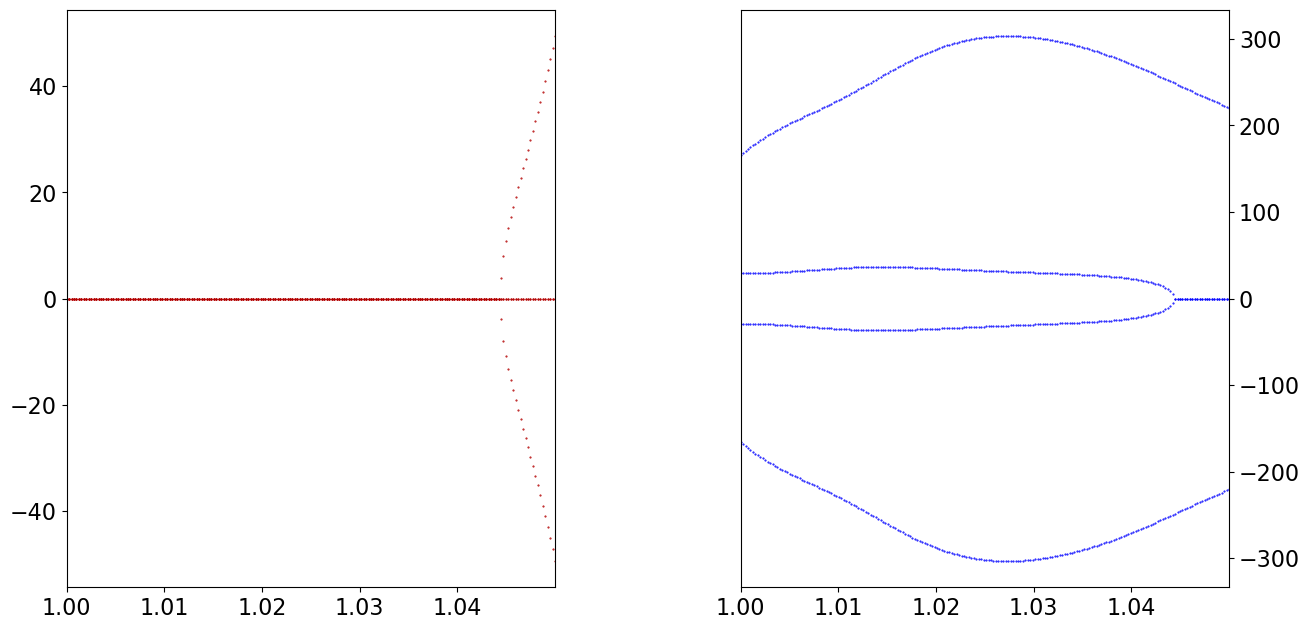

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, dummy, ax2) = plt.subplots(nrows=1, ncols=3, width_ratios=(1,0.1,1))
dummy.axis('off')
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)
    ax2.plot(wavelengths,np.imag(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorImag, fillstyle='full',  color=colorImag)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

(-0.004, 0.001)

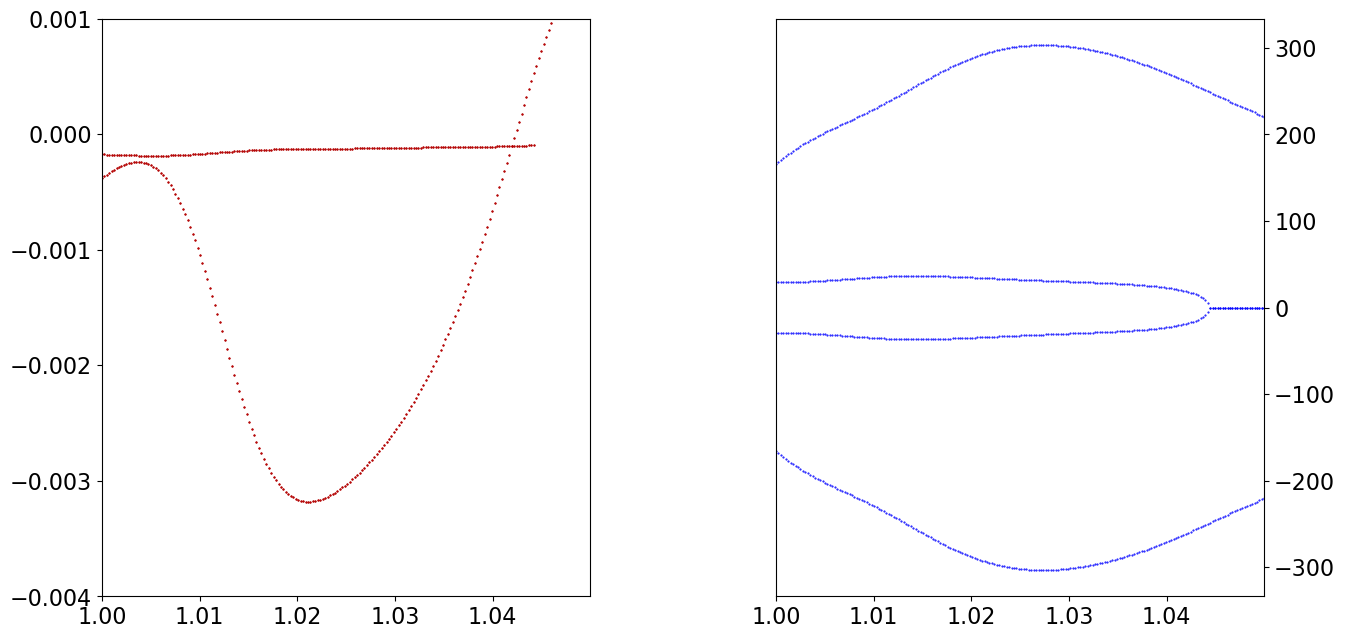

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, dummy, ax2) = plt.subplots(nrows=1, ncols=3, width_ratios=(1,0.1,1))
dummy.axis('off')
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)
    ax2.plot(wavelengths,np.imag(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorImag, fillstyle='full',  color=colorImag)

ax1.set_xlim((1, 1.4))
ax2.set_xlim((1, 1.4))
#ax1.set_ylim((-0.004, 0.001))